# QS-Net (PyTorch Version)
## Version 1: CICIoT2023 | 500 Training (Weighted) | Batch Size 64 | 30 Epochs (Early Stopping) | LR 0.05
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
import pennylane as qp
from pennylane import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix, classification_report

import json
from pathlib import Path
import time
from collections import Counter

In [2]:
from scripts.constants import DEFAULT_CF, DEFAULT_NOISE_RATE, ZERO_DAY
from scripts.data import (
    class_balance_table,
    load_split,
    plot_class_balance_pie,
    plot_class_balance_bars,
    stratified_head,
)
from scripts.circuit import build_forward_circuit, create_quantum_device, initialize_weights
from scripts.conformal import calibrate_threshold
from scripts.prototypes import PrototypeBank, compute_prototypes
from scripts.loss import maqt_loss, gradient_variance
from scripts.logging import write_history_log
from scripts.inference import estimate_lipschitz, predict_batch, predict_labels
from scripts.utils import get_torch_device, to_np_x, to_torch_x

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: CICIoT2023

In [4]:
dataset = "CICIoT2023"
data_path = f"data/{dataset}/quantum"
target_col = "label_multiclass"
split_prefix = "q8"

In [5]:
df = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [6]:
print(df["label_multiclass"].unique())
print()
print(df["label_family"].unique())

<ArrowStringArray>
[       'DDoS-RSTFINFlood',           'BenignTraffic',
         'DDoS-ICMP_Flood',          'DDoS-TCP_Flood',
 'DDoS-SynonymousIP_Flood',          'DDoS-SlowLoris',
       'DDoS-PSHACK_Flood',           'DoS-TCP_Flood',
          'DDoS-UDP_Flood',           'DoS-UDP_Flood',
          'DoS-HTTP_Flood',          'DDoS-SYN_Flood',
           'DoS-SYN_Flood',        'MITM-ArpSpoofing',
    'DictionaryBruteForce',            'DNS_Spoofing',
  'DDoS-UDP_Fragmentation',          'Recon-PortScan',
       'VulnerabilityScan',                     'XSS',
         'DDoS-HTTP_Flood', 'DDoS-ICMP_Fragmentation',
  'DDoS-ACK_Fragmentation',     'Recon-HostDiscovery',
            'Recon-OSScan',        'BrowserHijacking',
         'Recon-PingSweep',            'SqlInjection',
        'Backdoor_Malware',        'CommandInjection',
        'Uploading_Attack']
Length: 31, dtype: str

<ArrowStringArray>
[                       'ddos',                      'benign',
                      

In [7]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [8]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['Backdoor_Malware',
 'BenignTraffic',
 'BrowserHijacking',
 'CommandInjection',
 'DDoS-ACK_Fragmentation',
 'DDoS-HTTP_Flood',
 'DDoS-ICMP_Flood',
 'DDoS-ICMP_Fragmentation',
 'DDoS-PSHACK_Flood',
 'DDoS-RSTFINFlood',
 'DDoS-SYN_Flood',
 'DDoS-SlowLoris',
 'DDoS-SynonymousIP_Flood',
 'DDoS-TCP_Flood',
 'DDoS-UDP_Flood',
 'DDoS-UDP_Fragmentation',
 'DNS_Spoofing',
 'DictionaryBruteForce',
 'DoS-HTTP_Flood',
 'DoS-SYN_Flood',
 'DoS-TCP_Flood',
 'DoS-UDP_Flood',
 'MITM-ArpSpoofing',
 'Recon-HostDiscovery',
 'Recon-OSScan',
 'Recon-PingSweep',
 'Recon-PortScan',
 'SqlInjection',
 'Uploading_Attack',
 'VulnerabilityScan',
 'XSS']

In [9]:
# load all data
X_train_full, y_train_full = load_split(data_path, f"{split_prefix}_train", target_col, class_names)
X_cal_full, y_cal_full = load_split(data_path, f"{split_prefix}_calibration", target_col, class_names)
X_test_full, y_test_full = load_split(data_path, f"{split_prefix}_test", target_col, class_names)
X_val_full, y_val_full = load_split(data_path, f"{split_prefix}_val", target_col, class_names)

In [10]:
# check shape
[X_train_full.shape, y_train_full.shape], [X_cal_full.shape, y_cal_full.shape], [X_test_full.shape, y_test_full.shape], [X_val_full.shape, y_val_full.shape]

([(132166, 8), (132166,)],
 [(18883, 8), (18883,)],
 [(18883, 8), (18883,)],
 [(18883, 8), (18883,)])

## EDA (Before Class-Weighting)

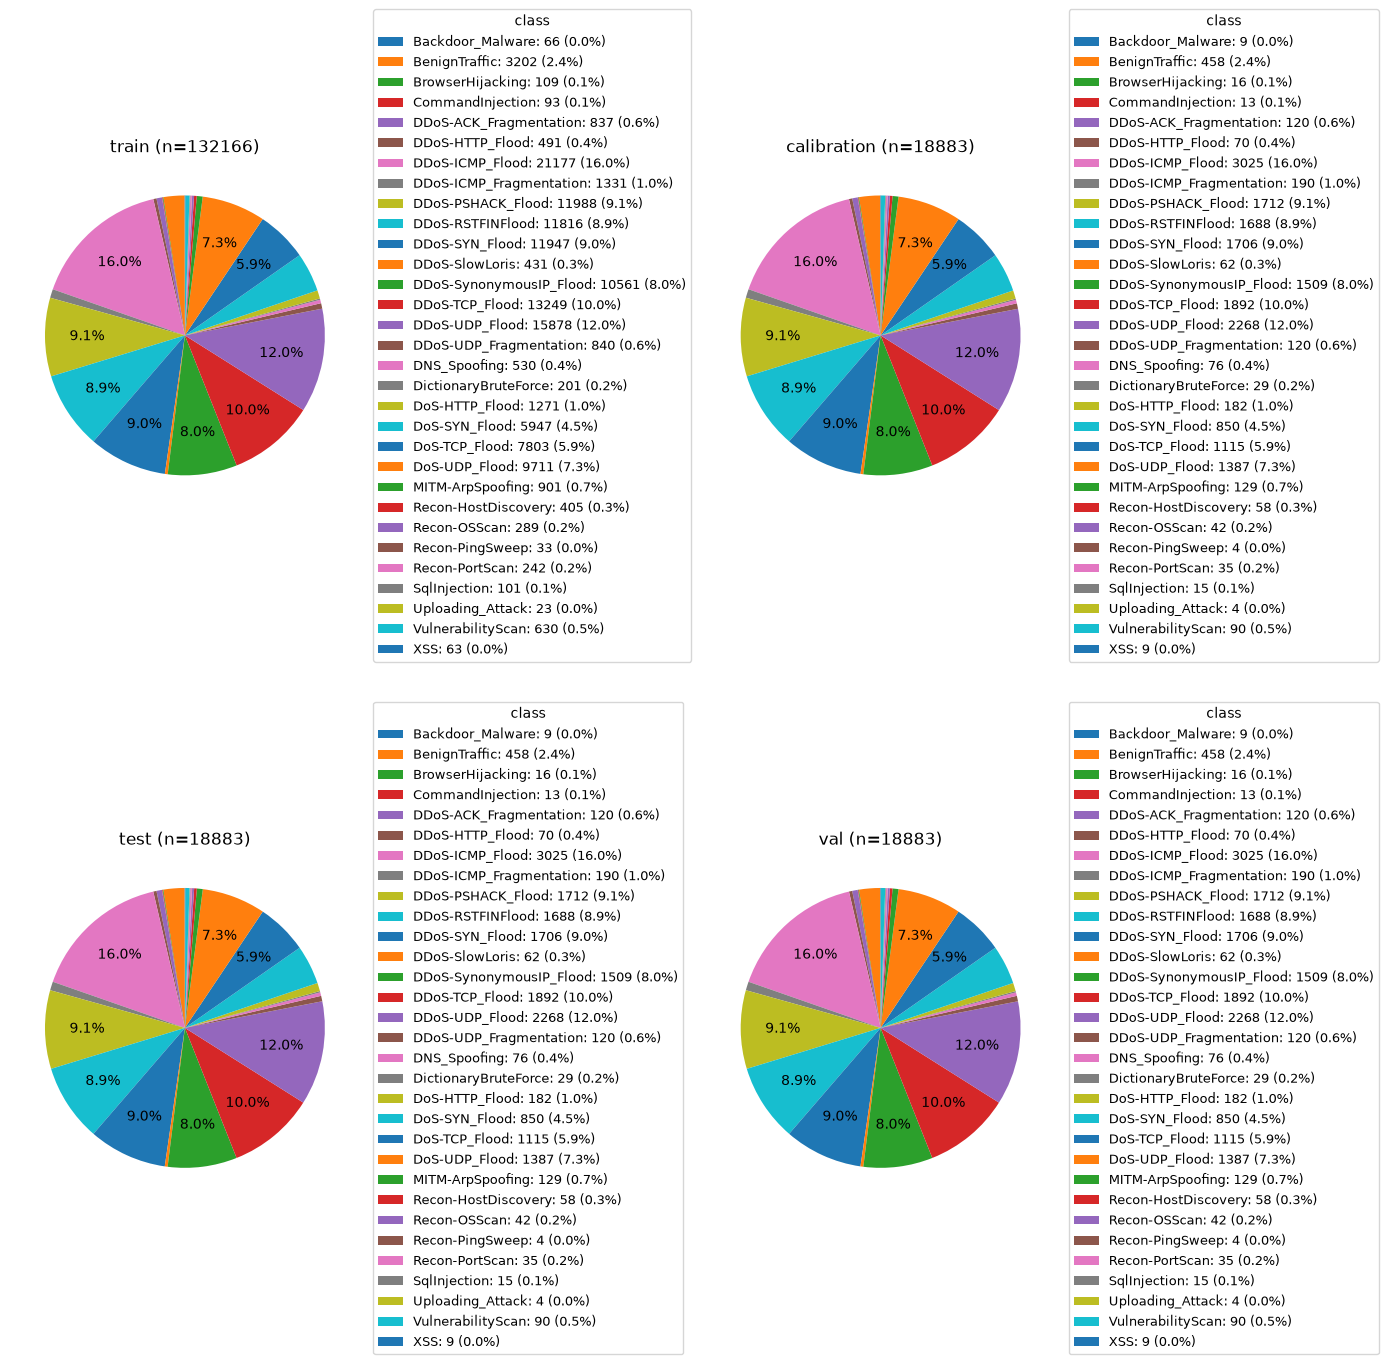

In [11]:
# pie chart
splits = {
    "train": y_train_full,
    "calibration": y_cal_full,
    "test": y_test_full,
    "val": y_val_full,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, (name, y) in zip(axes.ravel(), splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_x(y))})", ax=ax)

plt.tight_layout()
plt.show()

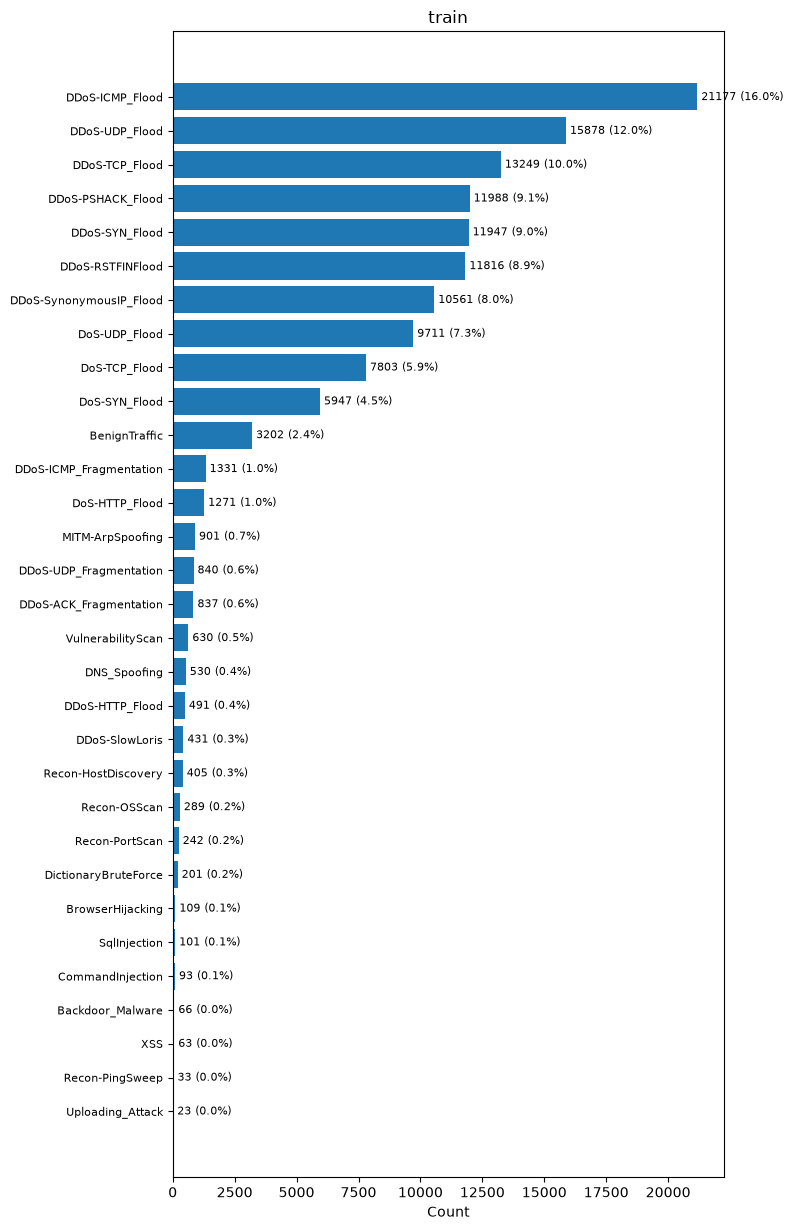

In [12]:
plot_class_balance_bars(y_train_full, class_names, title="train")
plt.show()

## Class Weighting, Data Subset

- Rebalance **training only** (tempered class-weighted CE).
- Keep **val / calibration / test** unchanged (natural distribution).
- Do **not** use hard equal-count undersampling of every class.
- Do **not** use SMOTE after quantum encoding.
- Never train/tune on zero-day.

In [13]:
# uncomment to take subset
from scripts.data import stratified_head
X_train, y_train = stratified_head(X_train_full, y_train_full, 500, seed=42)
X_val, y_val = stratified_head(X_train_full, y_train_full, 50, seed=42)
X_cal, y_cal = stratified_head(X_train_full, y_train_full, 50, seed=42)
X_test, y_test = stratified_head(X_train_full, y_train_full, 50, seed=42)

In [14]:
# recompute tempered weights on the actual training y
y_np = to_np_x(y_train).astype(int)
counts = Counter(y_np.tolist())
raw = {c: 1.0 / (counts[c] ** 0.5) for c in counts}

# normalize to mean 1, then clip
mean_w = sum(raw.values()) / len(raw)
class_weight = {c: min(max(raw[c] / mean_w, 0.25), 4.0) for c in raw}

weight_tensor = torch.tensor(
    [class_weight.get(i, 1.0) for i in range(len(class_names))],
    dtype=torch.float32,
)

print("train class counts:", dict(sorted(counts.items())))
print()
print("tempered class weights:", {class_names[c]: round(class_weight[c], 3) for c in sorted(class_weight)})

train class counts: {0: 66, 1: 3202, 2: 109, 3: 93, 4: 837, 5: 491, 6: 21177, 7: 1331, 8: 11988, 9: 11816, 10: 11947, 11: 431, 12: 10561, 13: 13249, 14: 15878, 15: 840, 16: 530, 17: 201, 18: 1271, 19: 5947, 20: 7803, 21: 9711, 22: 901, 23: 405, 24: 289, 25: 33, 26: 242, 27: 101, 28: 23, 29: 630, 30: 63}

tempered class weights: {'Backdoor_Malware': 2.354, 'BenignTraffic': 0.338, 'BrowserHijacking': 1.831, 'CommandInjection': 1.983, 'DDoS-ACK_Fragmentation': 0.661, 'DDoS-HTTP_Flood': 0.863, 'DDoS-ICMP_Flood': 0.25, 'DDoS-ICMP_Fragmentation': 0.524, 'DDoS-PSHACK_Flood': 0.25, 'DDoS-RSTFINFlood': 0.25, 'DDoS-SYN_Flood': 0.25, 'DDoS-SlowLoris': 0.921, 'DDoS-SynonymousIP_Flood': 0.25, 'DDoS-TCP_Flood': 0.25, 'DDoS-UDP_Flood': 0.25, 'DDoS-UDP_Fragmentation': 0.66, 'DNS_Spoofing': 0.831, 'DictionaryBruteForce': 1.349, 'DoS-HTTP_Flood': 0.536, 'DoS-SYN_Flood': 0.25, 'DoS-TCP_Flood': 0.25, 'DoS-UDP_Flood': 0.25, 'MITM-ArpSpoofing': 0.637, 'Recon-HostDiscovery': 0.95, 'Recon-OSScan': 1.125, 'Rec

In [15]:
# check shape
[X_train.shape, y_train.shape], [X_cal.shape, y_cal.shape], [X_test.shape, y_test.shape], [X_val.shape, y_val.shape]

([(500, 8), (500,)], [(50, 8), (50,)], [(50, 8), (50,)], [(50, 8), (50,)])

## EDA (After Class-Weighting)

In [16]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"classes: {class_names}")
print(f"\nnumber of classes: {num_classes}")
print(f"\nnumber of qubits: {num_qubits}")

classes: ['Backdoor_Malware', 'BenignTraffic', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DictionaryBruteForce', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'SqlInjection', 'Uploading_Attack', 'VulnerabilityScan', 'XSS']

number of classes: 31

number of qubits: 8


In [17]:
# initialize devices
dev = qp.device("default.mixed", wires=num_qubits)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
# convert data type and move to device
X_train = to_torch_x(X_train, device)
y_train = to_torch_x(y_train, device).long()

# move weight tensor to device
weight_tensor = weight_tensor.to(device)

# verify
X_train[:5], y_train[:5], weight_tensor

(tensor([[0.0000, 0.0841, 0.0852, 0.0000, 0.0983, 1.0230, 0.1239, 1.2385],
         [0.0721, 0.0216, 0.2986, 0.6738, 0.1590, 1.0777, 0.1787, 3.1416],
         [0.0369, 0.5178, 0.1697, 0.3076, 0.1461, 1.0621, 0.1787, 3.1416],
         [0.1299, 0.0592, 0.1393, 0.0964, 0.1569, 1.0692, 0.1934, 3.1416],
         [0.0000, 0.0079, 0.0852, 0.0000, 0.0983, 1.0230, 0.1239, 1.2385]],
        device='cuda:0'),
 tensor([21, 19, 19, 19, 21], device='cuda:0'),
 tensor([1.0000, 0.6017, 2.0844, 1.0000, 1.2034, 1.4739, 0.2500, 0.9322, 0.3107,
         0.3107, 0.3107, 1.4739, 0.3296, 0.2948, 0.2691, 1.2034, 1.4739, 2.0844,
         0.9322, 0.4346, 0.3806, 0.3427, 1.2034, 1.4739, 2.0844, 1.0000, 2.0844,
         1.0000, 1.0000, 1.4739, 1.0000], device='cuda:0'))

In [19]:
# check shape
[X_train.shape, y_train.shape], [X_cal.shape, y_cal.shape], [X_test.shape, y_test.shape], [X_val.shape, y_val.shape]

([torch.Size([500, 8]), torch.Size([500])],
 [(50, 8), (50,)],
 [(50, 8), (50,)],
 [(50, 8), (50,)])

In [20]:
# table
splits = {
    "train": y_train,
    "calibration": y_cal,
    "test": y_test,
    "val": y_val,
}

for name, y in splits.items():
    table = class_balance_table(y, class_names)
    print(f"{name} (n={len(to_np_x(y))})")
    display(table)

train (n=500)


,class,count,pct
0,Backdoor_Malware,0,0.0
1,BenignTraffic,12,2.4
2,BrowserHijacking,1,0.2
3,CommandInjection,0,0.0
4,DDoS-ACK_Fragmentation,3,0.6
5,DDoS-HTTP_Flood,2,0.4
6,DDoS-ICMP_Flood,80,16.0
7,DDoS-ICMP_Fragmentation,5,1.0
8,DDoS-PSHACK_Flood,45,9.0
9,DDoS-RSTFINFlood,45,9.0


calibration (n=50)


,class,count,pct
0,Backdoor_Malware,0,0.0
1,BenignTraffic,1,2.0
2,BrowserHijacking,0,0.0
3,CommandInjection,0,0.0
4,DDoS-ACK_Fragmentation,0,0.0
5,DDoS-HTTP_Flood,0,0.0
6,DDoS-ICMP_Flood,8,16.0
7,DDoS-ICMP_Fragmentation,1,2.0
8,DDoS-PSHACK_Flood,5,10.0
9,DDoS-RSTFINFlood,5,10.0


test (n=50)


,class,count,pct
0,Backdoor_Malware,0,0.0
1,BenignTraffic,1,2.0
2,BrowserHijacking,0,0.0
3,CommandInjection,0,0.0
4,DDoS-ACK_Fragmentation,0,0.0
5,DDoS-HTTP_Flood,0,0.0
6,DDoS-ICMP_Flood,8,16.0
7,DDoS-ICMP_Fragmentation,1,2.0
8,DDoS-PSHACK_Flood,5,10.0
9,DDoS-RSTFINFlood,5,10.0


val (n=50)


,class,count,pct
0,Backdoor_Malware,0,0.0
1,BenignTraffic,1,2.0
2,BrowserHijacking,0,0.0
3,CommandInjection,0,0.0
4,DDoS-ACK_Fragmentation,0,0.0
5,DDoS-HTTP_Flood,0,0.0
6,DDoS-ICMP_Flood,8,16.0
7,DDoS-ICMP_Fragmentation,1,2.0
8,DDoS-PSHACK_Flood,5,10.0
9,DDoS-RSTFINFlood,5,10.0


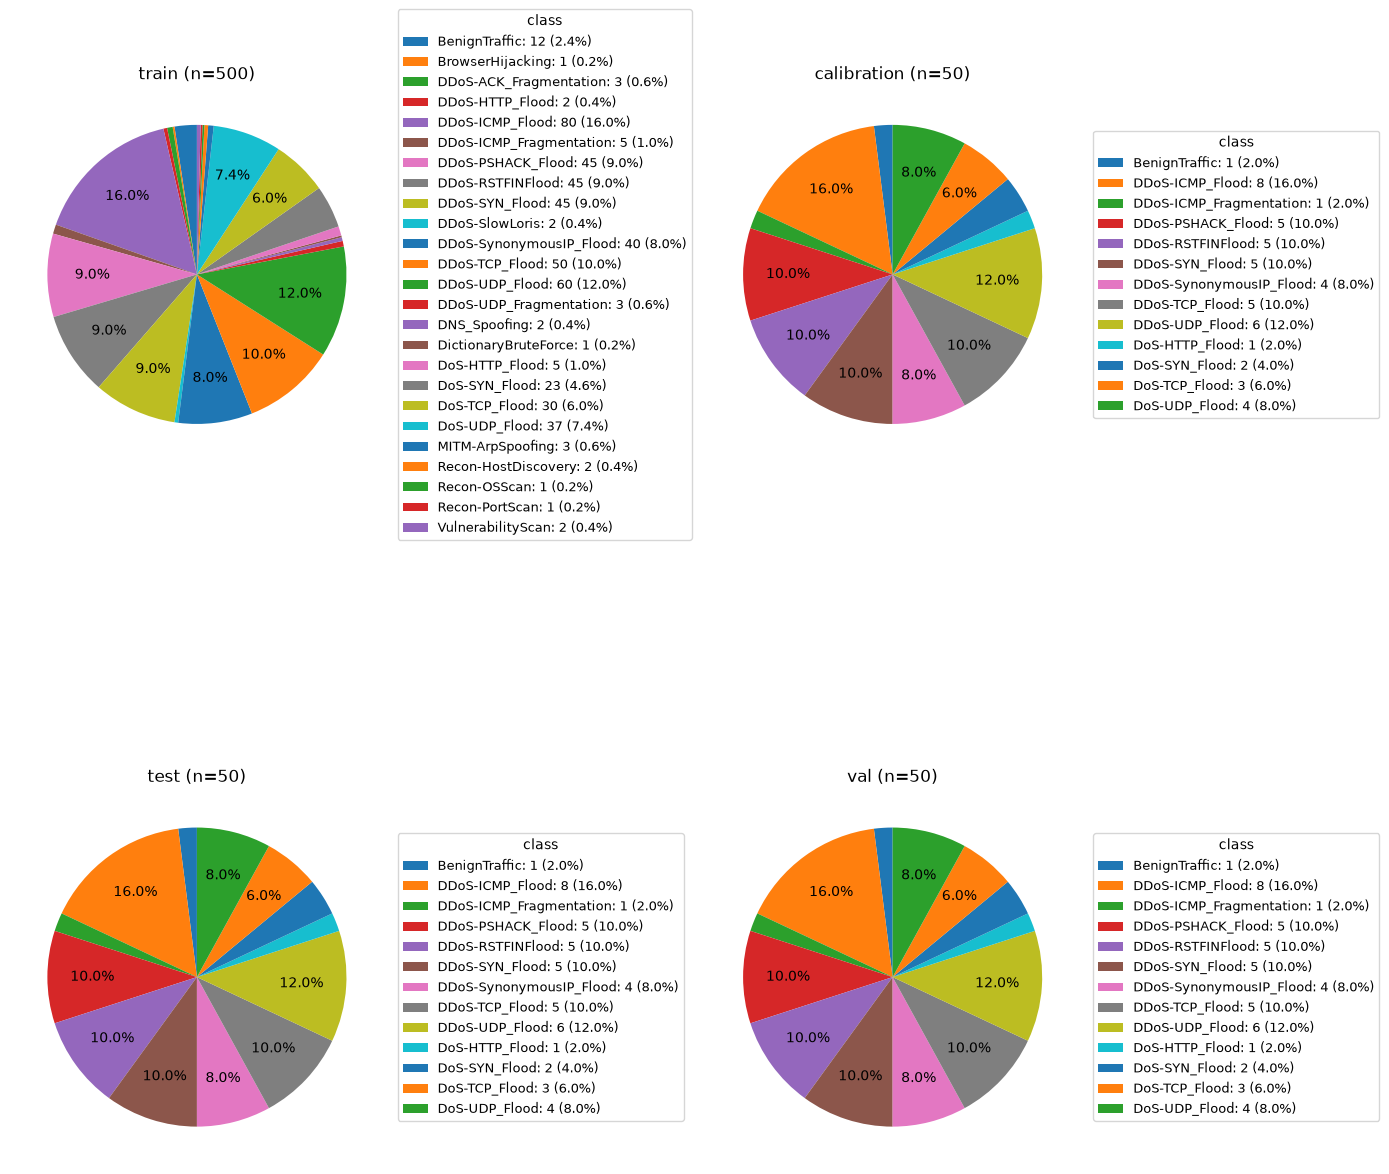

In [21]:
# pie chart
splits = {
    "train": y_train,
    "calibration": y_cal,
    "test": y_test,
    "val": y_val,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, (name, y) in zip(axes.ravel(), splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_x(y))})", ax=ax)

plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [22]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [23]:
# initialize deviceSize
dev = create_quantum_device(num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

# initialize weights
theta = initialize_weights(num_layers, num_qubits, device)

# define classifier head
classifier_head = nn.Linear(num_qubits, num_classes).to(device)

In [24]:
# initialize weights
theta = initialize_weights(num_layers, num_qubits, device)
theta.shape

torch.Size([2, 8, 3])

In [25]:
# DEBUG
theta

Parameter containing:
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]], device='cuda:0', requires_grad=True)

## Helper

In [26]:
import copy

class EarlyStopping:
    """
    track best score; signal stop after `patience` non-improving epochs.
    """

    def __init__(self, patience=3, min_delta=0.0, mode="max"):
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.mode = mode
        self.best_score = None
        self.bad_epochs = 0
        self.should_stop = False
        self.best_epoch = 0

    def step(self, score, epoch):
        score = float(score)
        improved = False

        if self.best_score is None:
            improved = True
        elif self.mode == "max":
            improved = score > self.best_score + self.min_delta
        else:
            improved = score < self.best_score - self.min_delta

        if improved:
            self.best_score = score
            self.best_epoch = epoch
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1
            if self.bad_epochs >= self.patience:
                self.should_stop = True

        return improved, self.should_stop


def snapshot_trainable(theta, classifier_head):
    return {
        "theta": copy.deepcopy(theta.detach().cpu()),
        "classifier_head": copy.deepcopy(classifier_head.state_dict()),
    }


def restore_trainable(theta, classifier_head, snapshot, device):
    with torch.no_grad():
        theta.copy_(snapshot["theta"].to(device))
    classifier_head.load_state_dict(snapshot["classifier_head"])
    classifier_head.to(device)

## Training

Minimizing:
- $L_{CE}$ adjusts $\theta$ for better class predictions.
- $L_{intra}$ pulls each sample toward its class prototype
- $L_{inter}$ pushs different-class prototypes apart (maximize trace distance)

In [27]:
lambda1 = 0.5
lambda2 = 0.3
epochs = 30
batch_size = 64
lr = 0.05

barren_plateau_var = 1e-6
COMPUTE_GRAD_VAR = True

IMBALANCE_MODE = "class_weighted_ce"

patience = 3
min_delta = 0.0  # require this much F1 gain to count as improvement

In [28]:
# define loss function
if IMBALANCE_MODE == "class_weighted_ce":
    ce_loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)  # experiment A
elif IMBALANCE_MODE == "weighted_sampler":
    ce_loss_fn = nn.CrossEntropyLoss()  # experiment B: unweighted CE
else:
    raise ValueError(f"unknown IMBALANCE_MODE={IMBALANCE_MODE}")

# define optimizer
optimizer = torch.optim.Adam(list([theta]) + list(classifier_head.parameters()), lr=lr)

# define prototype bank
prototype_bank = PrototypeBank(range(num_classes))

In [29]:
history = {
    "loss": [], "l_ce": [], "l_intra": [], "l_inter": [],
    "grad_var": [], "barren_plateau": [],
    "val_macro_f1": [], "epoch_sec": [],
}

# initialize early stopping
early_stop = EarlyStopping(patience=patience, min_delta=min_delta, mode="max")
best_snapshot = snapshot_trainable(theta, classifier_head)

# compute batches
num_batches = (len(X_train) + batch_size - 1) // batch_size
print(f"training: {len(X_train)} samples, {num_batches} batches/epoch, {epochs} epochs")

# training
train_t0 = time.perf_counter()
for epoch in range(epochs):
    epoch_t0 = time.perf_counter()
    prototype_bank.reset()
    perm = torch.randperm(len(X_train), device=device)

    epoch_grad_vars = []
    epoch_loss, epoch_ce, epoch_intra, epoch_inter = [], [], [], []

    for batch_idx, start in enumerate(range(0, len(perm), batch_size)):
        print(f"epoch {epoch + 1} batch {batch_idx}/{num_batches - 1}", flush=True)

        idx = perm[start : start + batch_size]
        X_batch, y_batch = X_train[idx], y_train[idx]

        # running prototype update for classes present in this batch
        for x, label in zip(X_batch, y_batch):
            _, rho_x = forward_circuit(x, theta)
            prototype_bank.update(int(label.item()), rho_x)
        batch_prototypes = prototype_bank.means()

        # compute loss
        loss, L_CE, L_intra, L_inter = maqt_loss(
            theta, classifier_head, ce_loss_fn,
            X_batch, y_batch, batch_prototypes, forward_circuit,
            lambda1=lambda1, lambda2=lambda2, device=device,
        )

        # clear old grads to compute new ones
        optimizer.zero_grad()
        loss.backward()

        if COMPUTE_GRAD_VAR:
            gvar, _ = gradient_variance(
                theta, classifier_head, ce_loss_fn,
                X_batch, y_batch, batch_prototypes, forward_circuit,
                lambda1=lambda1, lambda2=lambda2, device=device,
            )
            epoch_grad_vars.append(gvar)

        # update weights
        optimizer.step()

        epoch_loss.append(float(loss.item()))
        epoch_ce.append(float(L_CE.item()))
        epoch_intra.append(float(L_intra.item()))
        epoch_inter.append(float(L_inter.item()))

    # check barren plateau
    mean_gvar = float(np.mean(epoch_grad_vars)) if epoch_grad_vars else 0.0
    plateau = mean_gvar < barren_plateau_var

    history["loss"].append(float(np.mean(epoch_loss)))
    history["l_ce"].append(float(np.mean(epoch_ce)))
    history["l_intra"].append(float(np.mean(epoch_intra)))
    history["l_inter"].append(float(np.mean(epoch_inter)))
    history["grad_var"].append(mean_gvar)
    history["barren_plateau"].append(plateau)

    # val macro-F1
    y_true, y_pred = predict_labels(X_val, y_val, theta, classifier_head, forward_circuit, device)
    val_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    history["val_macro_f1"].append(float(val_f1))
    history["epoch_sec"].append(time.perf_counter() - epoch_t0)

    # early stopping    
    improved, stop = early_stop.step(val_f1, epoch=epoch + 1)
    if improved:
        best_snapshot = snapshot_trainable(theta, classifier_head)
    
    print(
        f"epoch {epoch + 1:02d}/{epochs} | "
        f"loss={history['loss'][-1]:.4f} | "
        f"l_ce={history['l_ce'][-1]:.4f} | "
        f"l_intra={history['l_intra'][-1]:.4f} | "
        f"l_inter={history['l_inter'][-1]:.4f} | "
        f"val_macro_f1={val_f1:.4f} | "
        f"best={early_stop.best_score:.4f}@ep{early_stop.best_epoch} | "
        f"bad={early_stop.bad_epochs}/{patience} | "
        f"grad_var={mean_gvar:.2e} | barren_plateau={plateau} | "
        f"time={history['epoch_sec'][-1]:.1f}s"
    )

    if stop:
        print(
            f"early stopping at epoch {epoch + 1}: "
            f"no val_macro_f1 improvement for {patience} epochs "
            f"(best={early_stop.best_score:.4f} @ epoch {early_stop.best_epoch})"
        )
        break

# restore best weights before prototypes / conformal / test
restore_trainable(theta, classifier_head, best_snapshot, device)

print(
    f"training done in {(time.perf_counter() - train_t0) / 60:.1f} min | "
    f"using best epoch {early_stop.best_epoch} (val_macro_f1={early_stop.best_score:.4f})"
)

theta_star = theta
prototypes = compute_prototypes(
    theta_star, X_train, y_train, range(num_classes),
    forward_circuit=forward_circuit, device=device,
)

training: 500 samples, 8 batches/epoch, 30 epochs
epoch 1 batch 0/7
epoch 1 batch 1/7
epoch 1 batch 2/7
epoch 1 batch 3/7
epoch 1 batch 4/7
epoch 1 batch 5/7
epoch 1 batch 6/7
epoch 1 batch 7/7
epoch 01/30 | loss=2.8815 | l_ce=3.0348 | l_intra=0.1956 | l_inter=-0.8372 | val_macro_f1=0.0511 | best=0.0511@ep1 | bad=0/3 | grad_var=1.49e-03 | barren_plateau=False | time=352.6s
epoch 2 batch 0/7
epoch 2 batch 1/7
epoch 2 batch 2/7
epoch 2 batch 3/7
epoch 2 batch 4/7
epoch 2 batch 5/7
epoch 2 batch 6/7
epoch 2 batch 7/7
epoch 02/30 | loss=2.2224 | l_ce=2.3699 | l_intra=0.2025 | l_inter=-0.8290 | val_macro_f1=0.0867 | best=0.0867@ep2 | bad=0/3 | grad_var=1.24e-03 | barren_plateau=False | time=351.9s
epoch 3 batch 0/7
epoch 3 batch 1/7
epoch 3 batch 2/7
epoch 3 batch 3/7
epoch 3 batch 4/7
epoch 3 batch 5/7
epoch 3 batch 6/7
epoch 3 batch 7/7
epoch 03/30 | loss=1.9628 | l_ce=2.1097 | l_intra=0.1842 | l_inter=-0.7969 | val_macro_f1=0.0678 | best=0.0867@ep2 | bad=1/3 | grad_var=8.07e-04 | barren_

In [30]:
# save prototypes (all-in-one checkpoint)
out_dir = Path("models/prototypes") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "theta": theta_star.detach().cpu(),
        "classifier_head": classifier_head.state_dict(),
        "prototypes": {int(c): rho.detach().cpu() for c, rho in prototypes.items()},
        "class_names": list(class_names),
        "num_qubits": num_qubits,
        "num_layers": num_layers,
        "noise_rate": noise_rate,
        "lambda1": lambda1,
        "lambda2": lambda2,
        "dataset": dataset,
        "data_path": data_path,
        "target_col": target_col,
        "split_prefix": "q8",
    },
    out_dir / "training-qs-net-prototypes_v3.0-checkpoint.pt",
)
print("published:", out_dir.resolve())

published: /home/lawun330/Desktop/qsentinel/quantum-sentinel/models/prototypes/CICIoT2023


In [31]:
# write log (temporarily after training)
log_path = write_history_log(
    history,
    notebook="training-qs-net-prototypes_v3.0.ipynb",
    extra={
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "lambda1": lambda1,
        "lambda2": lambda2,
    },
    log_dir="logs"
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/qsentinel/quantum-sentinel/logs/training-qs-net-prototypes_v3.0.log


In [32]:
# DEBUG
theta_star

Parameter containing:
tensor([[[ 0.0000,  0.3624,  0.0000],
         [ 0.0000,  0.2181,  0.0000],
         [ 0.0000, -0.2926,  0.0000],
         [ 0.0000, -0.1428,  0.0000],
         [ 0.0000, -0.2240,  0.0000],
         [ 0.0000, -0.8899,  0.0000],
         [ 0.0000, -0.2857,  0.0000],
         [ 0.0000, -0.7527,  0.0000]],

        [[ 0.0000,  0.9950,  0.0000],
         [ 0.0000,  0.0721,  0.0000],
         [ 0.0000, -0.0840,  0.0000],
         [ 0.0000, -0.1647,  0.0000],
         [ 0.0000, -0.0188,  0.0000],
         [ 0.0000, -0.9475,  0.0000],
         [ 0.0000,  0.1077,  0.0000],
         [ 0.0000, -0.1524,  0.0000]]], device='cuda:0', requires_grad=True)

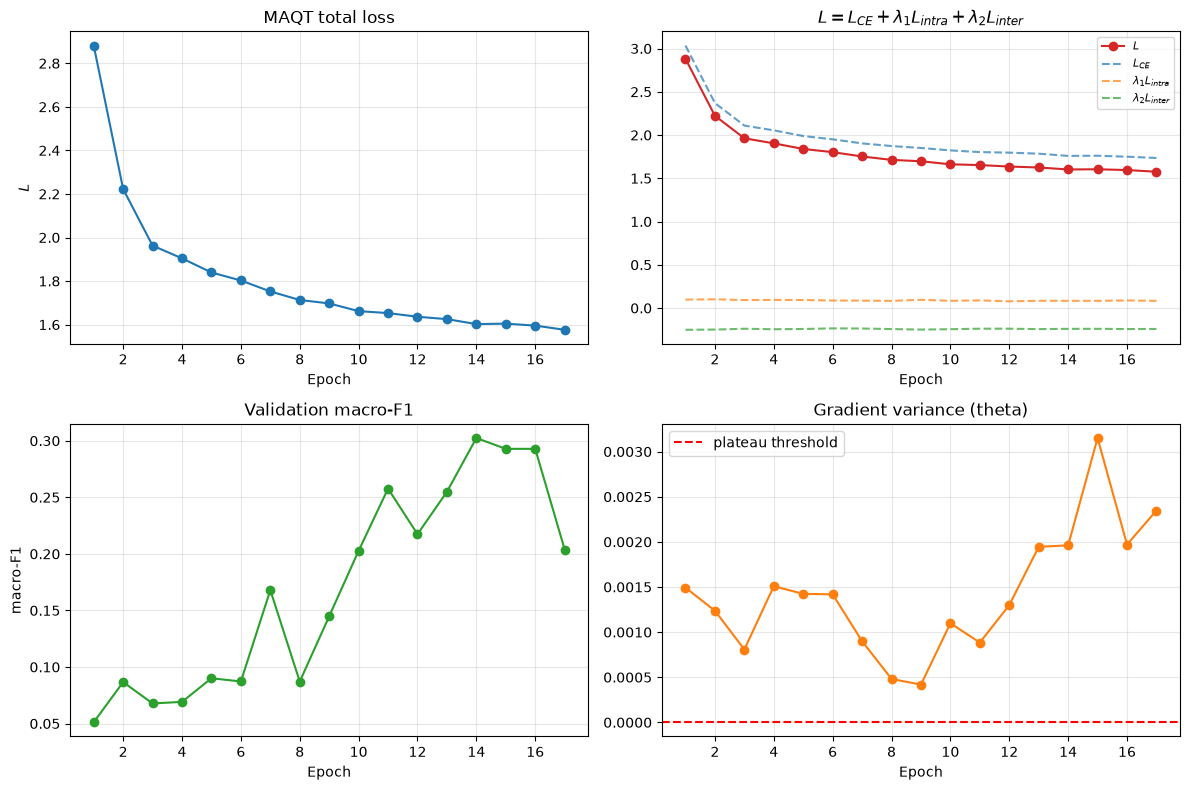

In [33]:
# plots
epochs_x = range(1, len(history["loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# MAQT total loss
axes[0, 0].plot(epochs_x, history["loss"], marker="o")
axes[0, 0].set_title("MAQT total loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel(r"$L$")
axes[0, 0].grid(True, alpha=0.3)

# decomposed MAQT
axes[0, 1].plot(epochs_x, history["loss"], marker="o", color="C3", label=r"$L$")
axes[0, 1].plot(epochs_x, history["l_ce"], "--", alpha=0.7, label=r"$L_{CE}$")
axes[0, 1].plot(
    epochs_x,
    [lambda1 * v for v in history["l_intra"]],
    "--", alpha=0.7, label=rf"$\lambda_1 L_{{intra}}$",
)
axes[0, 1].plot(
    epochs_x,
    [lambda2 * v for v in history["l_inter"]],
    "--", alpha=0.7, label=rf"$\lambda_2 L_{{inter}}$",
)
axes[0, 1].set_title(r"$L = L_{CE}+\lambda_1 L_{intra}+\lambda_2 L_{inter}$")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# validation macro-F1
axes[1, 0].plot(epochs_x, history["val_macro_f1"], marker="o", color="tab:green")
axes[1, 0].set_title("Validation macro-F1")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("macro-F1")
axes[1, 0].grid(True, alpha=0.3)

# gradient variance
axes[1, 1].plot(epochs_x, history["grad_var"], marker="o", color="tab:orange")
axes[1, 1].axhline(barren_plateau_var, color="red", linestyle="--", label="plateau threshold")
axes[1, 1].set_title("Gradient variance (theta)")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Algo 2: Conformal Zero-Day Threshold Calibration (CQ-ZDR)

Nonconformity score: $s_i = 1 - \max_c F(\rho(x_i), \rho_c)$.

Split-conformal threshold: $q = s_{(k)}$ with $k = \lceil (1 - \alpha)(n + 1) \rceil$.

In [34]:
alpha = 0.05
q, scores_sorted = calibrate_threshold(theta_star, X_cal, prototypes, forward_circuit, alpha=alpha, device=device)
print(f"conformal threshold q = {q:.4f} (alpha={alpha}, n_cal={len(X_cal)})")

conformal threshold q = 0.4723 (alpha=0.05, n_cal=50)


## Algo 3: Unified Inference with Disentangled Rejection

At test time, one pass produces either
- a class label with a certified robustness radius $\rightarrow$ `(label, certified_radius)`, or
- a zero-day flag $\rightarrow$ `(ZERO_DAY, 0)`.

In [35]:
# estimate Lipschitz constant
L_phi = estimate_lipschitz(X_train, theta_star, forward_circuit, n_probe=30, delta=0.05, device=device)
print(f"estimated L_phi = {L_phi:.4f}")

estimated L_phi = 2.5631


## Evaluation on Known Test Samples

### Evaluation with Classifier-Head Only

[head] test accuracy: 0.4800
[head] test macro-F1: 0.1268
                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00         0
          BenignTraffic       0.00      0.00      0.00         1
       BrowserHijacking       0.00      0.00      0.00         0
       CommandInjection       0.00      0.00      0.00         0
 DDoS-ACK_Fragmentation       0.00      0.00      0.00         0
        DDoS-HTTP_Flood       0.00      0.00      0.00         0
        DDoS-ICMP_Flood       0.67      1.00      0.80         8
DDoS-ICMP_Fragmentation       1.00      1.00      1.00         1
      DDoS-PSHACK_Flood       1.00      1.00      1.00         5
       DDoS-RSTFINFlood       0.00      0.00      0.00         5
         DDoS-SYN_Flood       0.00      0.00      0.00         5
         DDoS-SlowLoris       0.00      0.00      0.00         0
DDoS-SynonymousIP_Flood       0.24      1.00      0.38         4
         DDoS-TCP_Flood       0

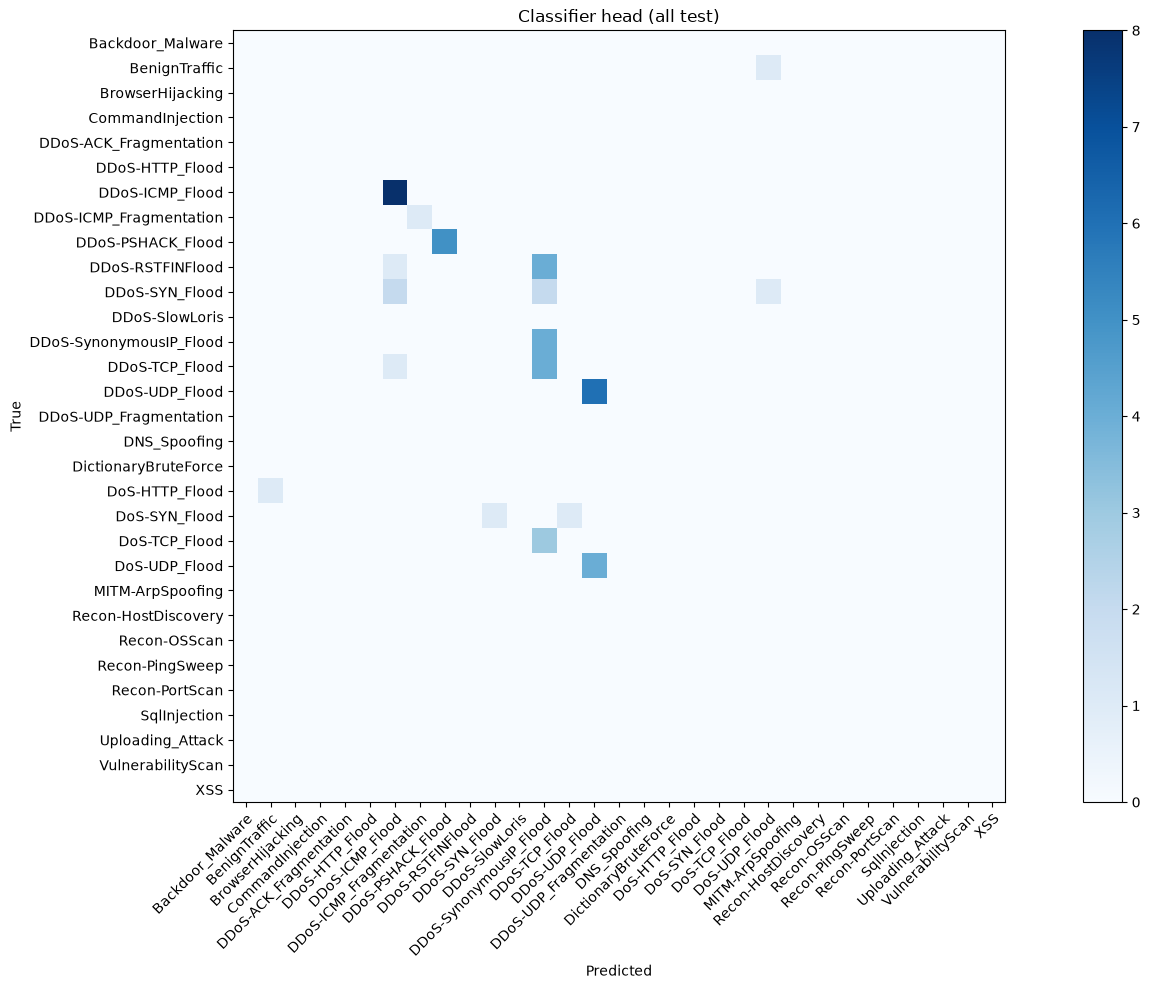

In [36]:
label_ids = list(range(num_classes))

y_true_head, y_pred_head = predict_labels(
    X_test, y_test, theta_star, classifier_head, forward_circuit, device
)

classifier_head_acc = float(np.mean(y_true_head == y_pred_head))
classifier_head_macro_f1 = float(
    f1_score(y_true_head, y_pred_head, average="macro", labels=label_ids, zero_division=0)
)

print(f"[head] test accuracy: {classifier_head_acc:.4f}")
print(f"[head] test macro-F1: {classifier_head_macro_f1:.4f}")
print(classification_report(
    y_true_head, y_pred_head,
    labels=label_ids, target_names=class_names, zero_division=0,
))

cm_head = confusion_matrix(y_true_head, y_pred_head, labels=label_ids)

fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(cm_head, interpolation="nearest", cmap="Blues")
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted",
    ylabel="True",
    title="Classifier head (all test)",
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

### Evaluation with QS-Net Pipeline

[pipeline] rejection rate on test: 0.0200
[pipeline] accepted known-sample test accuracy: 0.4286
[pipeline] accepted known-sample test macro-F1: 0.1386
[pipeline] accepted known-sample mean certified radius: 0.0080

[pipeline] classification report (accepted only):
                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00         0
          BenignTraffic       0.00      0.00      0.00         0
       BrowserHijacking       0.00      0.00      0.00         0
       CommandInjection       0.00      0.00      0.00         0
 DDoS-ACK_Fragmentation       0.00      0.00      0.00         0
        DDoS-HTTP_Flood       0.00      0.00      0.00         0
        DDoS-ICMP_Flood       0.67      1.00      0.80         8
DDoS-ICMP_Fragmentation       1.00      1.00      1.00         1
      DDoS-PSHACK_Flood       0.00      0.00      0.00         5
       DDoS-RSTFINFlood       0.00      0.00      0.00         5
         DDoS-SYN_

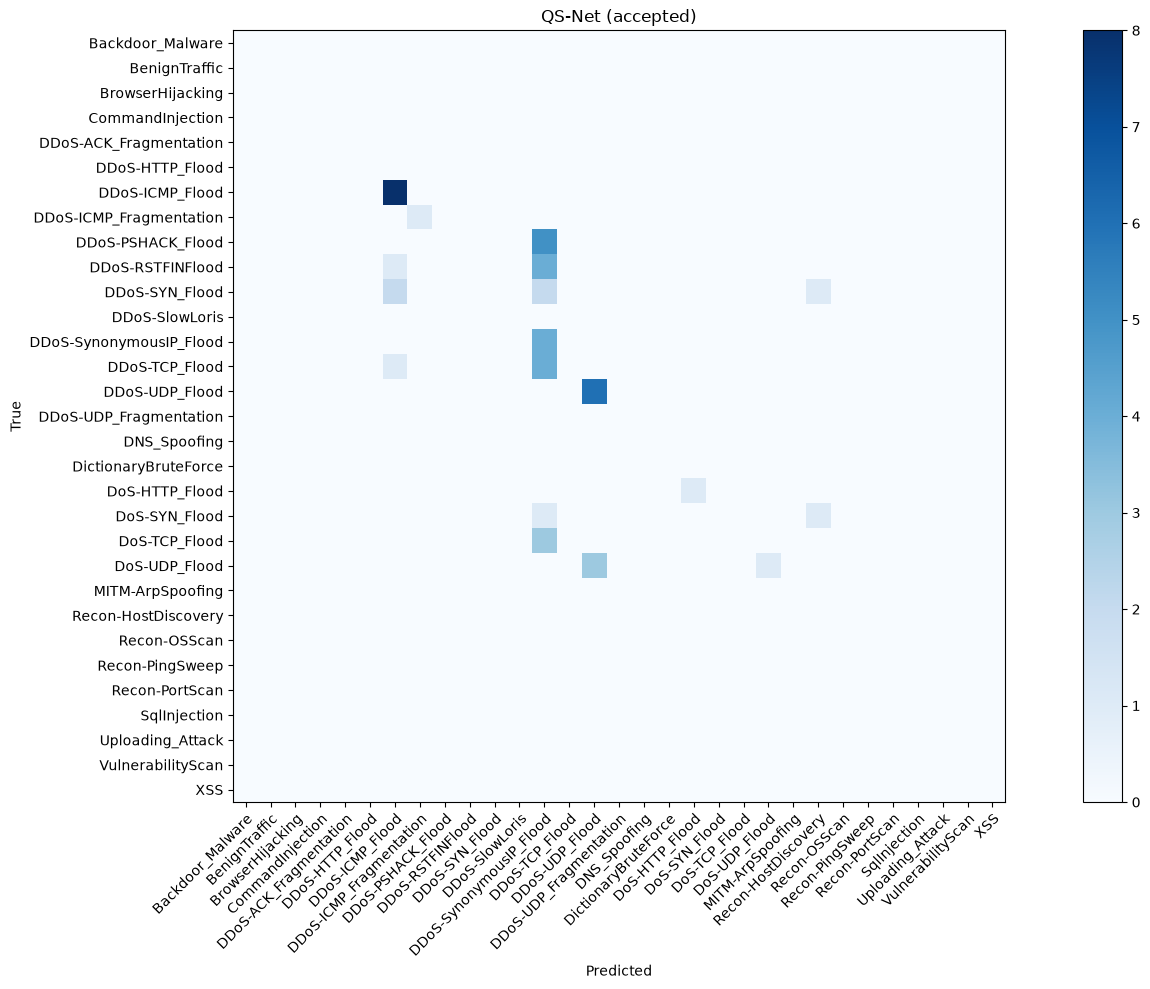

In [37]:
y_pred, radii, novelty_scores = predict_batch(
    X_test, theta_star, prototypes, q, forward_circuit,
    p=noise_rate, L_phi=L_phi, Cf=DEFAULT_CF, device=device,
)

y_test_np = to_np_x(y_test).astype(int)
known_mask = y_pred != ZERO_DAY
pipeline_reject_rate = float(1.0 - known_mask.mean())
pipeline_acc = float(np.mean(y_pred[known_mask] == y_test_np[known_mask])) if known_mask.any() else 0.0
pipeline_macro_f1 = float(
    f1_score(y_test_np[known_mask], y_pred[known_mask], average="macro", labels=label_ids, zero_division=0)
)
pipeline_radius_mean = float(radii[known_mask].mean()) if known_mask.any() else float('nan')

print(f"[pipeline] rejection rate on test: {pipeline_reject_rate:.4f}")
print(f"[pipeline] accepted known-sample test accuracy: {pipeline_acc:.4f}")
print(f"[pipeline] accepted known-sample test macro-F1: {pipeline_macro_f1:.4f}")
print(f"[pipeline] accepted known-sample mean certified radius: {pipeline_radius_mean:.4f}")

if known_mask.any():
    print("\n[pipeline] classification report (accepted only):")
    print(classification_report(
        y_test_np[known_mask], y_pred[known_mask],
        labels=label_ids, target_names=class_names, zero_division=0,
    ))

    cm = confusion_matrix(y_test_np[known_mask], y_pred[known_mask], labels=label_ids)

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="QS-Net (accepted)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.tight_layout()
    plt.show()


### Zero-Day Evaluation

In [38]:
df_zero = pd.read_parquet(f"{data_path}/{split_prefix}_zeroday.parquet")
df_zero

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.000000,0.341720,1.277049,0.000000,1.514452,2.111827,1.857477,1.238534,Mirai-udpplain,1,botnet_mirai
1,0.000000,0.306510,1.277049,1.002109,1.509367,2.106110,1.768736,1.238534,Mirai-udpplain,1,botnet_mirai
2,0.000000,0.000000,1.310114,0.000000,1.554586,2.141878,1.905572,3.141593,Mirai-greeth_flood,1,botnet_mirai
3,0.000000,0.000000,1.310114,0.000000,1.554586,2.141878,1.905572,3.141593,Mirai-greeth_flood,1,botnet_mirai
4,0.000000,0.000000,1.289592,1.503306,1.443681,2.066674,1.619096,3.141593,Mirai-greip_flood,1,botnet_mirai
...,...,...,...,...,...,...,...,...,...,...,...
10979,0.000000,0.000000,1.310114,0.025668,1.554562,2.141858,1.905229,3.141593,Mirai-greeth_flood,1,botnet_mirai
10980,0.003711,0.261604,1.277049,0.812117,1.510923,2.107637,1.812738,1.238534,Mirai-udpplain,1,botnet_mirai
10981,0.004044,0.002500,1.310114,0.973688,1.550295,2.137578,1.829819,3.141593,Mirai-greeth_flood,1,botnet_mirai
10982,0.007714,0.002847,1.310114,0.691768,1.553024,2.139929,1.872115,3.141593,Mirai-greeth_flood,1,botnet_mirai


In [39]:
feature_cols = [c for c in df_zero.columns if not c.startswith("label")]

X_zero = df_zero[feature_cols].values.astype(np.float32)
y_zero = df_zero[target_col].values

In [40]:
X_zero = X_zero[:20]
y_zero = y_zero[:20]

In [41]:
y_zero_pred, radii_zero, scores_zero = predict_batch(X_zero, theta_star, prototypes, q, forward_circuit,
                                                    p=DEFAULT_NOISE_RATE,
                                                    L_phi=L_phi,
                                                    Cf=DEFAULT_CF,
                                                    zero_day=ZERO_DAY,
                                                    device=device)

detected = y_zero_pred == ZERO_DAY
detection_rate = (detected).mean()

print(f"detected as ZERO_DAY: {detected.sum()} / {len(X_zero)} ({detection_rate:.1%})")
print(f"incorrectly accepted: {(~detected).sum()}")
print(f"mean novelty score: {scores_zero.mean():.4f} | threshold q: {q:.4f}")

if (~detected).any():
    for i in np.where(~detected)[0]:
        print(f"  accepted idx={i} true={y_zero[i]} pred={class_names[y_zero_pred[i]]} score={scores_zero[i]:.4f}")

detected as ZERO_DAY: 20 / 20 (100.0%)
incorrectly accepted: 0
mean novelty score: 0.7976 | threshold q: 0.4723


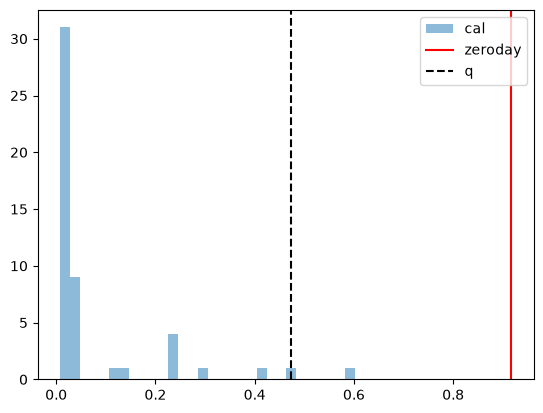

In [42]:
plt.hist(scores_sorted, bins=30, alpha=0.5, label="cal")
plt.axvline(scores_zero[0], color="r", label="zeroday")
plt.axvline(q, color="k", linestyle="--", label="q")
plt.legend(); plt.show()

## Logging

In [43]:
for k in history.keys():
    print(k)

loss
l_ce
l_intra
l_inter
grad_var
barren_plateau
val_macro_f1
epoch_sec


In [44]:
# write log (final)
log_path = write_history_log(
    history,
    notebook="training-qs-net-prototypes_v3.0.ipynb",
    extra={
        "label_column": "label_multiclass",
        "imbalance_mode": IMBALANCE_MODE,
        "dataset": dataset,
        "class_names": list(class_names),

        # algo 1: MAQT train
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "lambda1": lambda1,
        "lambda2": lambda2,

        ## quantum model
        "noise_rate": noise_rate,
        "num_layers": num_layers,
        "num_qubits": num_qubits,
        "num_classes": num_classes,

        ## data
        "n_train": len(X_train),
        "n_val": len(X_val),
        "n_test": len(X_test),
        
        ## gradient variance
        "barren_plateau_var": barren_plateau_var,
        "compute_grad_var": COMPUTE_GRAD_VAR,
        "grad_var_last": float(history["grad_var"][-1]) if history["grad_var"] else None,
        "barren_plateau_any": bool(any(history["barren_plateau"])) if history["barren_plateau"] else None,

        ## validation
        "val_macro_f1_last": float(history["val_macro_f1"][-1]) if history["val_macro_f1"] else None,
        "val_macro_f1_best": float(max(history["val_macro_f1"])) if history["val_macro_f1"] else None,

        ## early stopping
        "train_total_sec": float(sum(history["epoch_sec"])) if history["epoch_sec"] else None,
        "early_stop_patience": patience,
        "early_stop_min_delta": min_delta,
        "best_epoch": early_stop.best_epoch,
        "best_val_macro_f1": early_stop.best_score,
        "stopped_early": early_stop.should_stop,

        ## testing: classifier head
        "head_test_acc": float(classifier_head_acc),
        "head_test_macro_f1": float(classifier_head_macro_f1),

        ## testing: QS-Net pipeline (prototypes + q + radius)
        "pipeline_n_accepted": int(known_mask.sum()),
        "pipeline_n_rejected": int((~known_mask).sum()),
        "pipeline_reject_rate": float(pipeline_reject_rate),
        "pipeline_acc_accepted": float(pipeline_acc),
        "pipeline_macro_f1_accepted": float(pipeline_macro_f1),
        "pipeline_radius_mean_accepted": float(pipeline_radius_mean),

        # algo 2: conformal
        "alpha": alpha,
        "q": float(q),
        "n_cal": len(X_cal),
        "cal_score_min": float(scores_sorted.min()),
        "cal_score_max": float(scores_sorted.max()),
        "cal_score_mean": float(scores_sorted.mean()),

        # algo 3: certified radius + zero-day
        "L_phi": float(L_phi),
        "Cf": float(DEFAULT_CF),
        "n_zero": int(len(X_zero)),
        "zero_day_detection_rate": float(detection_rate),
        "zero_day_incorrectly_accepted": int((~detected).sum()),
        "zero_day_score_mean": float(scores_zero.mean()),
        "zero_day_score_min": float(scores_zero.min()),
        "zero_day_score_max": float(scores_zero.max()),
    },
    log_dir="logs",
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/qsentinel/quantum-sentinel/logs/training-qs-net-prototypes_v3.0.log
